**Objective**

Identify patterns and trends in customer churn

Understand key features affecting churn

Prepare data for future machine learning models

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns

In [81]:
df = pd.read_csv('/content/netflix_customer_churn.csv')

In [6]:
df.head(5)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


Customer ID, is not required for churn analysis, So delete the customer id record

In [82]:
df=df.drop(columns=['customer_id'],axis=1)

In [13]:
df.shape

(5000, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   object 
 2   subscription_type       5000 non-null   object 
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   object 
 6   device                  5000 non-null   object 
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   object 
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 507.9+ KB


In [16]:
df.dtypes

,0
age,int64
gender,object
subscription_type,object
watch_hours,float64
last_login_days,int64
region,object
device,object
monthly_fee,float64
churned,int64
payment_method,object


In [20]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


**Data Cleaning**

In [21]:
df.isnull().sum()

,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0
payment_method,0


In [28]:
# create scaled version only for ML
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = ['watch_hours', 'monthly_fee', 'avg_watch_time_per_day']

In [29]:
df_scaled = df.copy()

df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

In [30]:
df_scaled.head(5)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,watch_hours_total
0,51,Other,Basic,0.133345,29,Africa,TV,0.000000,1,Gift Card,1,0.004979,Action,0.133345
1,47,Other,Standard,0.006251,19,Europe,Mobile,0.555556,1,Gift Card,5,0.000305,Sci-Fi,0.006251
2,27,Female,Standard,0.147749,10,Asia,TV,0.555556,0,Crypto,2,0.015038,Drama,0.147749
3,53,Other,Premium,0.040765,12,Oceania,TV,1.000000,1,Crypto,2,0.003556,Horror,0.040765
4,56,Other,Standard,0.017031,13,Africa,Mobile,0.555556,1,Crypto,2,0.001321,Action,0.017031


In [48]:
df=df.drop(columns=['watch_hours_total'])

**Univariate Analysis**

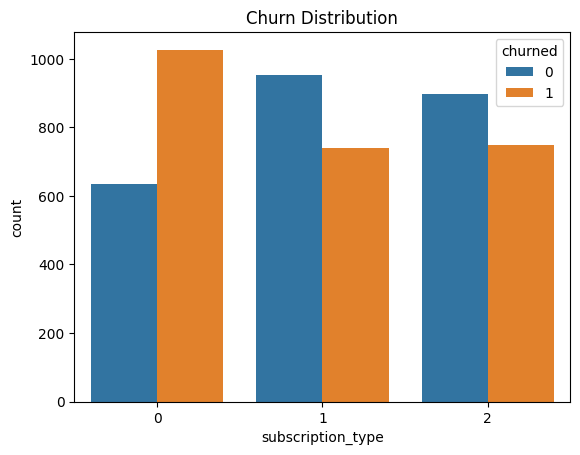

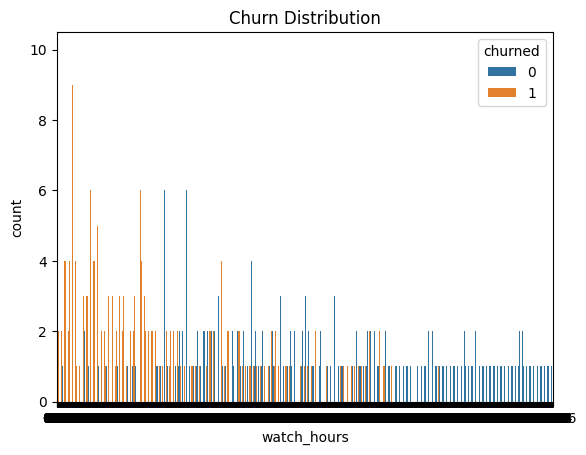

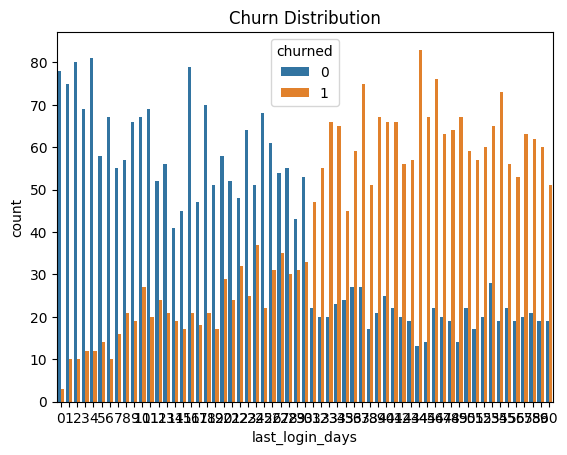

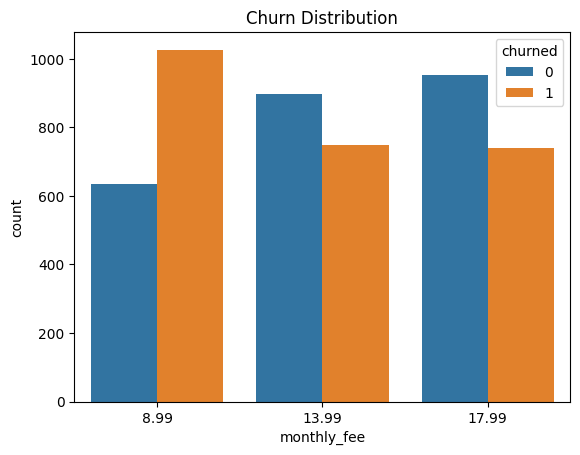

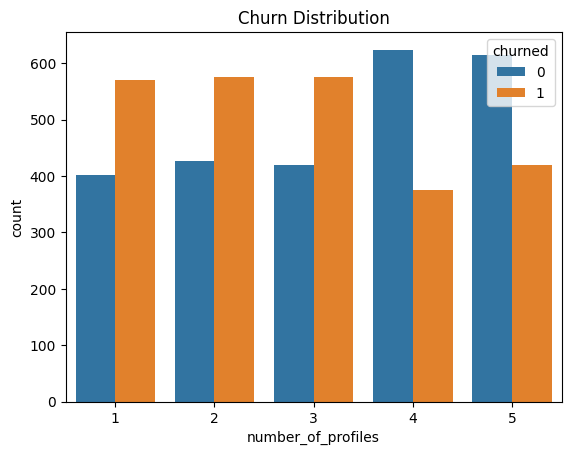

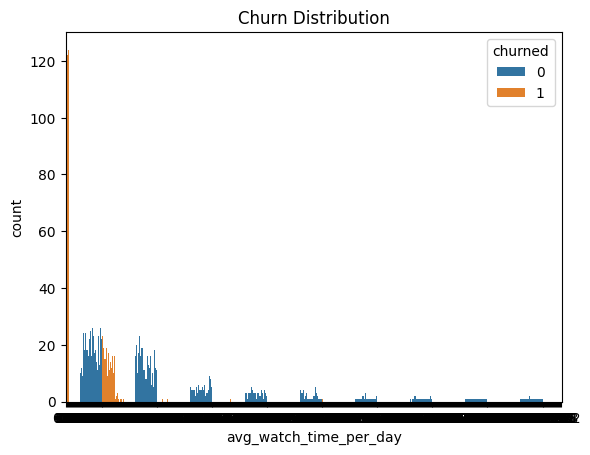

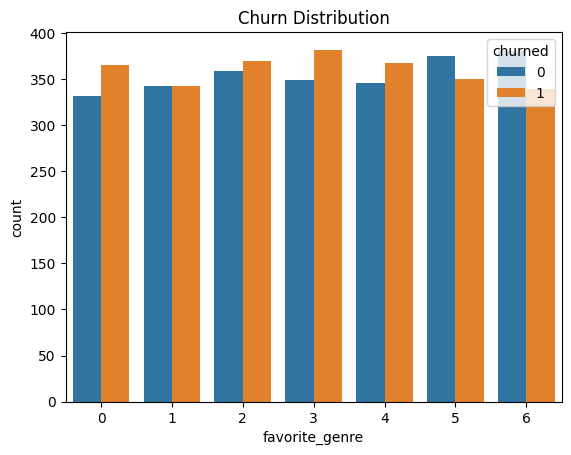

In [111]:
for i,p in enumerate(df.drop(columns=['churned']).columns):
  plt.figure(i)
  sns.countplot(data=df,x=p,hue='churned')
  plt.title("Churn Distribution")
  plt.show()

Churned depends on mainly last_day_login, watch_hours, monthly_fee, payment_method, subscription_type, number_of_profiles, avg_watch_time_per_day

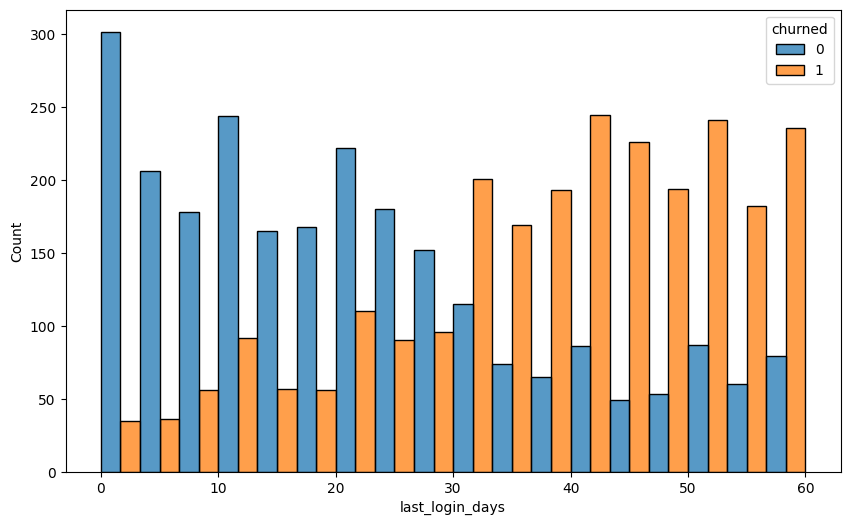

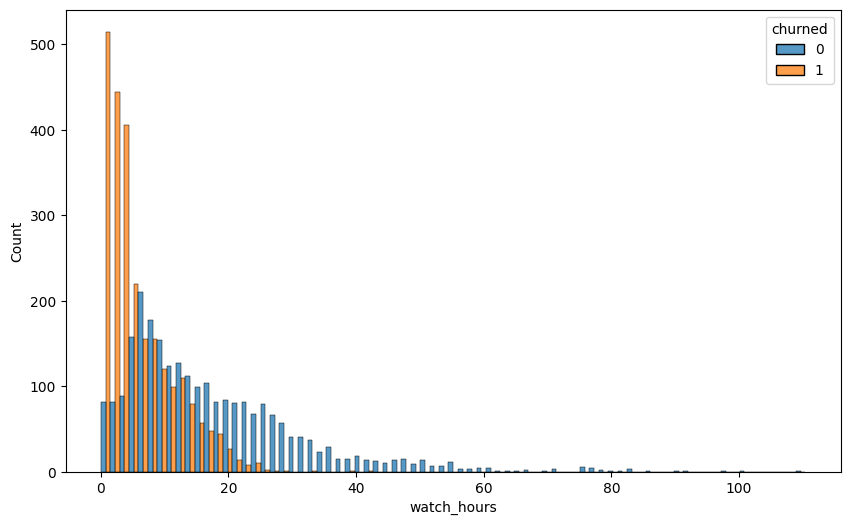

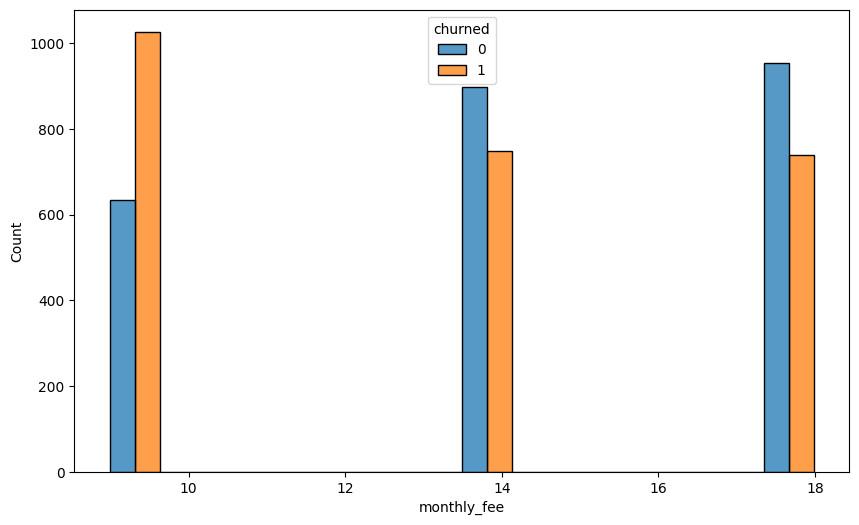

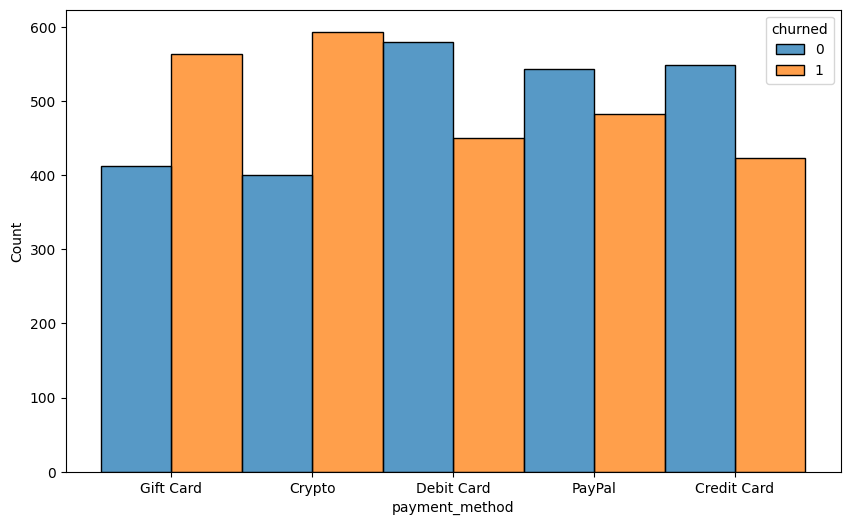

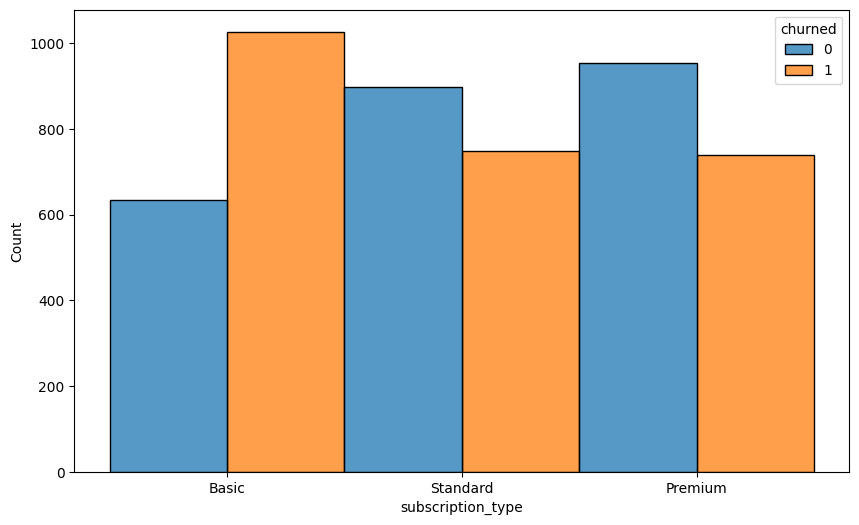

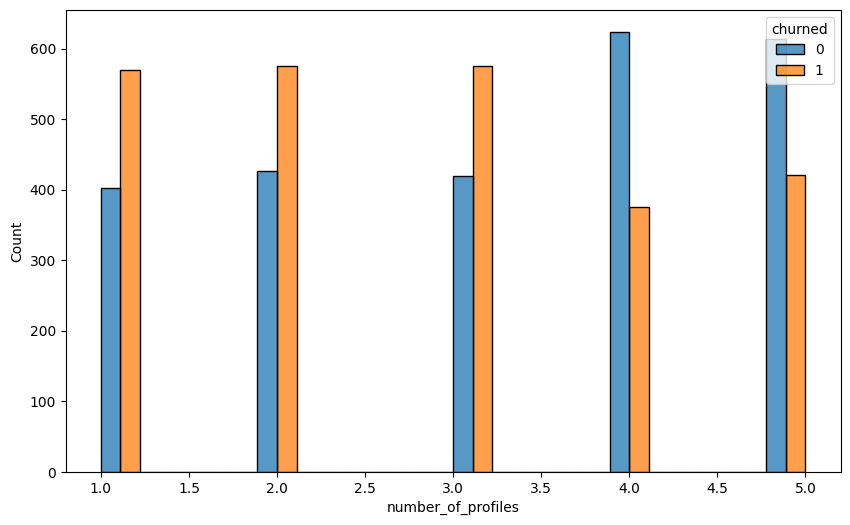

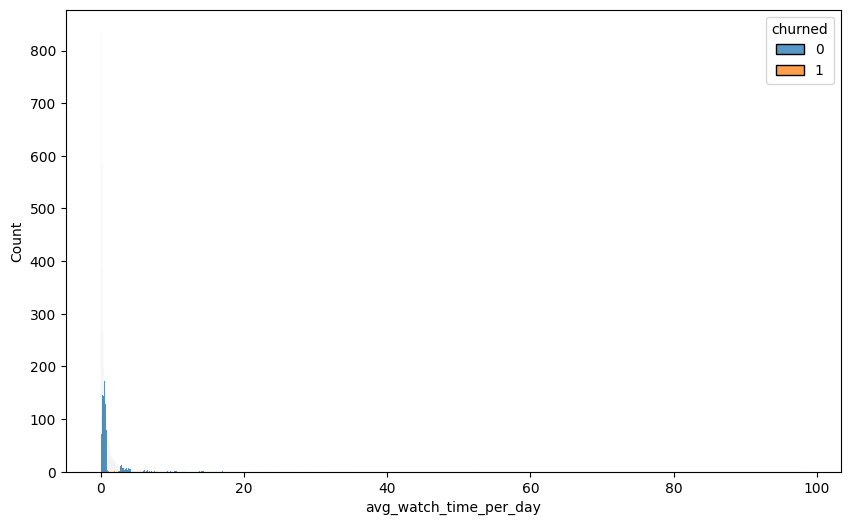

In [73]:
list = ['last_login_days', 'watch_hours', 'monthly_fee', 'payment_method', 'subscription_type', 'number_of_profiles', 'avg_watch_time_per_day']

for i in list:
  plt.figure(figsize=(10,6))
  sns.histplot(x=i,hue='churned',data=df,stat='count',multiple='dodge')

The more is last_login_days and watch_hours

<Axes: xlabel='last_login_days', ylabel='watch_hours'>

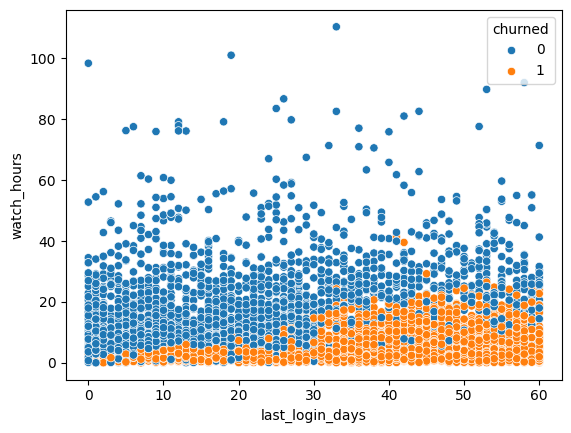

In [74]:
sns.scatterplot(x='last_login_days',y='watch_hours',data=df,hue='churned')

**Encoding**

In [78]:
df.dtypes


,0
age,category
gender,object
subscription_type,object
watch_hours,float64
last_login_days,int64
region,object
device,object
monthly_fee,float64
churned,int64
payment_method,object


In [94]:
le = preprocessing.LabelEncoder()
df['subscription_type'] = le.fit_transform(df['subscription_type'])
df['payment_method'] = le.fit_transform(df['payment_method'])
df['gender'] = le.fit_transform(df['gender'])
df['region'] = le.fit_transform(df['region'])
df['device'] = le.fit_transform(df['device'])
df['favorite_genre'] = le.fit_transform(df['favorite_genre'])


In [95]:
df.head(5)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,age_label
0,51,2,0,14.73,29,0,3,8.99,1,3,1,0.49,0,41-50
1,47,2,2,0.70,19,2,2,13.99,1,3,5,0.03,6,41-50
2,27,0,2,16.32,10,1,3,13.99,0,1,2,1.48,3,21-30
3,53,2,1,4.51,12,4,3,17.99,1,1,2,0.35,4,51-60
4,56,2,2,1.89,13,0,2,13.99,1,1,2,0.13,0,51-60


**Numerical Analysis**

<Axes: >

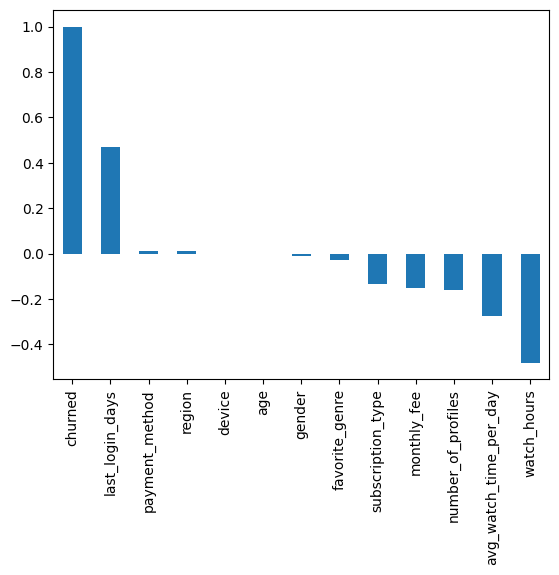

In [96]:
df.select_dtypes(include=['int64','float64']).corr()['churned'].sort_values(ascending=False).plot(kind='bar')

There is no relationship between age, gender(very Less),payment_method(very Less), region(very Less), device

In [99]:
df=df.drop(columns=['age','age_label','gender','payment_method','region','device'])

Text(0.5, 1.0, 'Correlation Matrix')

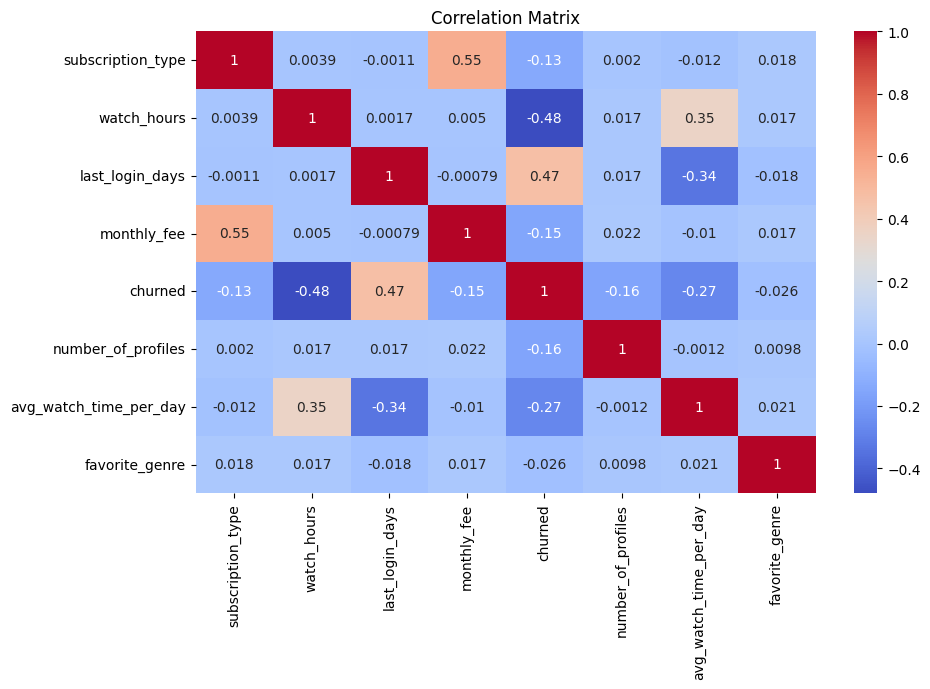

In [108]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")

**Key Findings**

Low engagement (watch hours) leads to higher churn

Subscription type significantly affects churn rate

Customers paying higher fees are more likely to leave

Behavioral factors are strong indicators of churn


**Supporting idea:**

Streaming platforms analyze user activity (like watch time) to reduce churn and improve retention strategies.

In [106]:
print("""
Insights:
1. Low watch hours customers churn more
2. Higher monthly fee increases churn
3. Certain subscription types have higher churn
4. Engaged users are less likely to churn
""")


Insights:
1. Low watch hours customers churn more
2. Higher monthly fee increases churn
3. Certain subscription types have higher churn
4. Engaged users are less likely to churn

